
=== FOLD 1/3 ===


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 177MB/s] 


Best Val F1: 0.3085

=== FOLD 2/3 ===


Best Val F1: 0.3885

=== FOLD 3/3 ===


Best Val F1: 0.2880

Generazione Grafici...


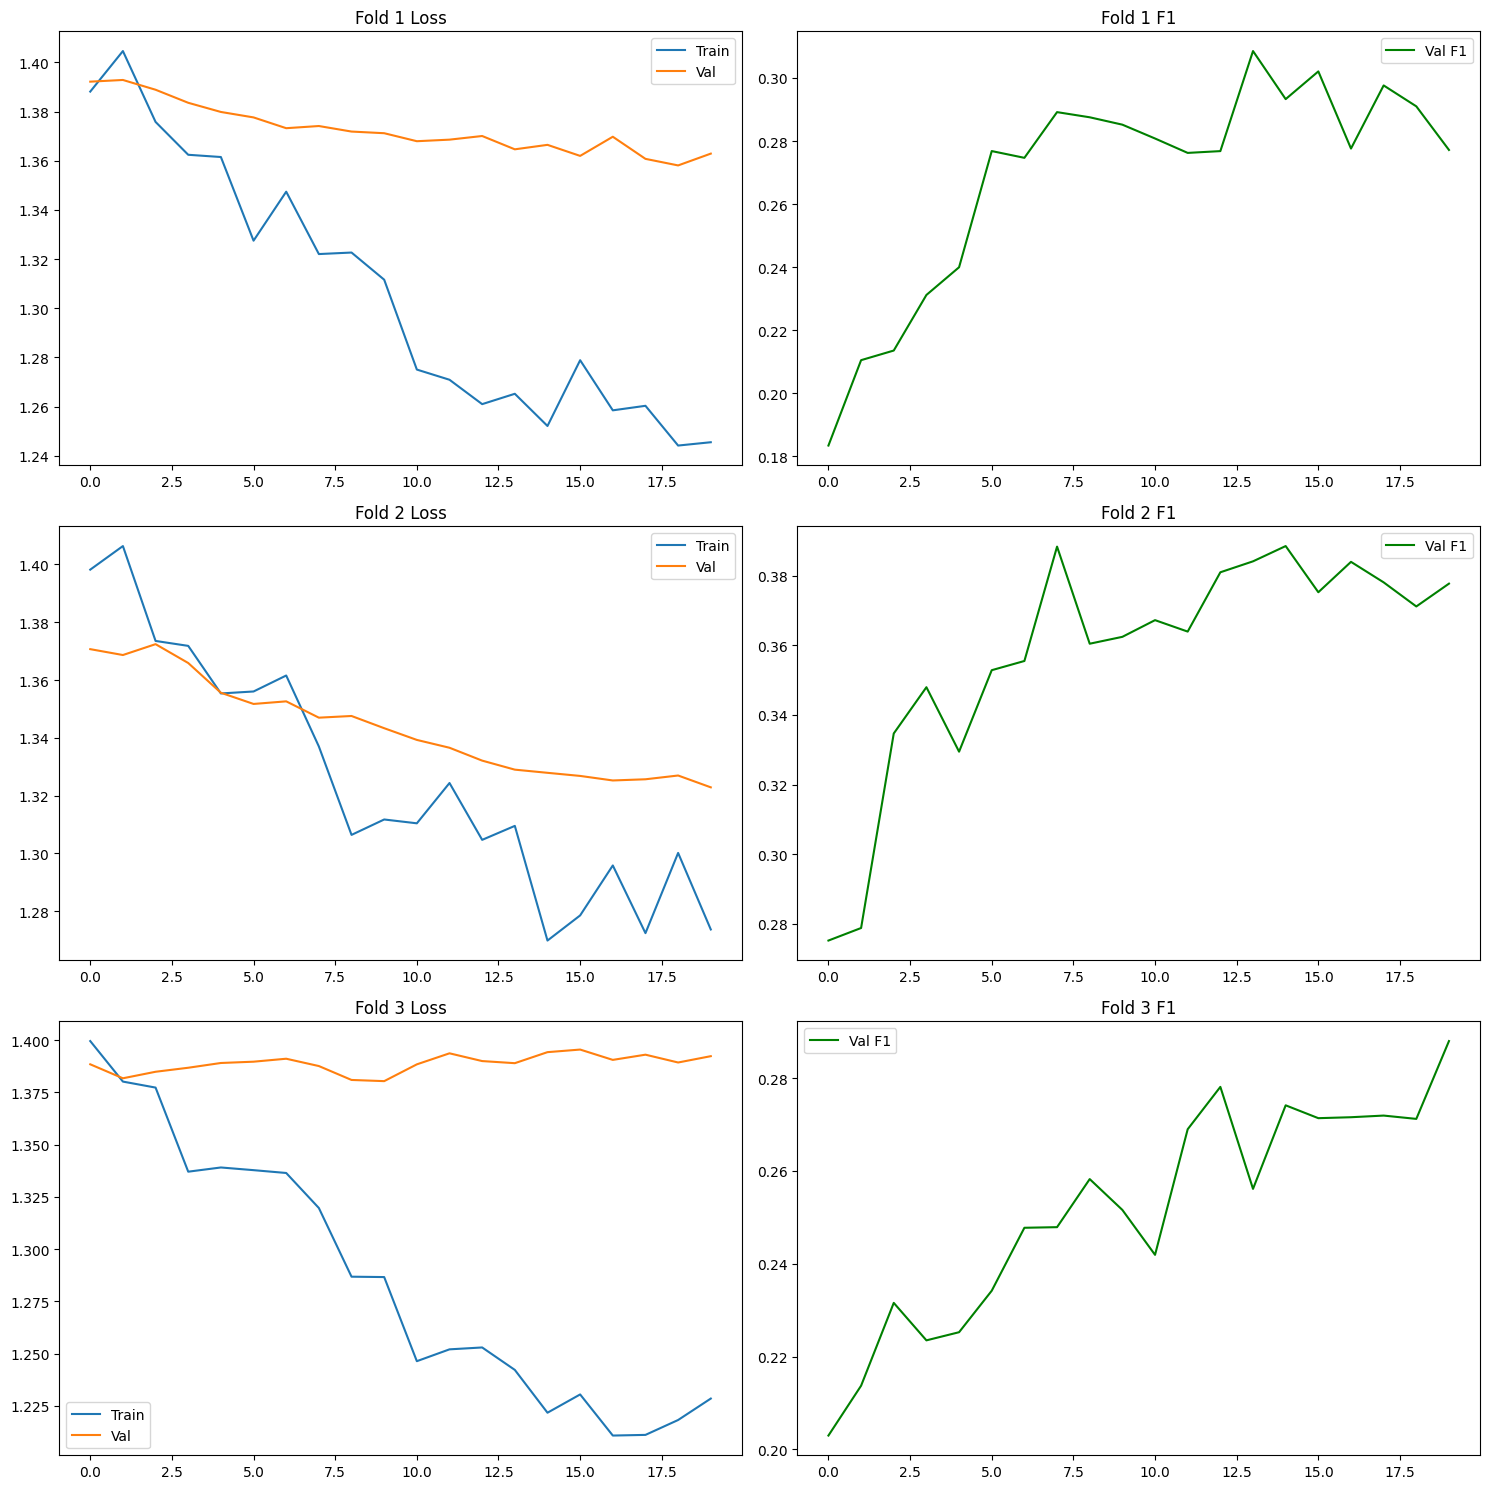

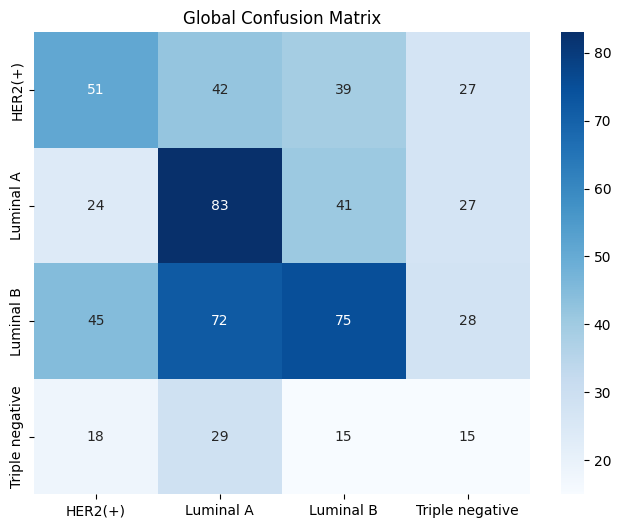


Generazione Submission...


100%|██████████| 30/30 [00:24<00:00,  1.22it/s]

Finito.


In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURAZIONE ROBUSTA ---
def find_paths():
    start_dir = "/kaggle/input"
    base_path = None
    for root, dirs, files in os.walk(start_dir):
        if "train_labels.csv" in files:
            base_path = root
            break
    if base_path is None: base_path = "/kaggle/input/dataset" 

    paths = {
        'labels': os.path.join(base_path, "train_labels.csv"),
        'train_img': os.path.join(base_path, "train_data/images"),
        'train_mask': os.path.join(base_path, "train_data/masks"),
        'test_img': os.path.join(base_path, "test_data/images"),
        'test_mask': os.path.join(base_path, "test_data/masks")
    }
    if not os.path.exists(paths['test_img']):
        for root, dirs, files in os.walk(start_dir):
            if root.endswith("test_data/images") or (os.path.basename(root) == "images" and "test_data" in os.path.dirname(root)):
                if any(f.endswith('.png') for f in files):
                    paths['test_img'] = root
                    paths['test_mask'] = root.replace("images", "masks")
                    break
    return paths

PATHS = find_paths()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
RESIZE_BASE = 320  # Dimensione base più grande
CROP_SIZE = 256    # Crop effettivo
BATCH_SIZE = 32    # Train Batch
VAL_BATCH_SIZE = 16 # Validation Batch (ridotto perché FiveCrop moltiplica per 5 la memoria)
N_FOLDS = 3
EPOCHS = 20
LR = 1e-4

# --- 2. DATASET ---
def get_bbox_from_mask(mask):
    if np.sum(mask) == 0: return None
    rows, cols = np.where(mask > 0)
    return np.min(rows), np.max(rows), np.min(cols), np.max(cols)

class TissueDataset(Dataset):
    def __init__(self, dataframe, img_dir, mask_dir, transform=None, is_test=False):
        self.df = dataframe
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['sample_index'] if not self.is_test else row['filename']
        mask_name = img_name.replace("img", "mask")
        
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)
        
        try:
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        except Exception:
            image = np.zeros((RESIZE_BASE, RESIZE_BASE, 3), dtype=np.uint8)
            mask = None

        if mask is not None:
            bbox = get_bbox_from_mask(mask)
            if bbox:
                y_min, y_max, x_min, x_max = bbox
                image = image[y_min:y_max+1, x_min:x_max+1]
        
        image = Image.fromarray(image)
        if self.transform: image = self.transform(image)
        
        if self.is_test: return image, img_name
        else: return image, torch.tensor(row['label_encoded'], dtype=torch.long)

# --- TRANSFORMS (TILING STRATEGY) ---
def get_transforms():
    # Train: Resize grande + Random Crop (Simula Tiling)
    train_trans = transforms.Compose([
        transforms.Resize((RESIZE_BASE, RESIZE_BASE)),
        transforms.RandomCrop(CROP_SIZE), 
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # Val/Test: FiveCrop (4 angoli + centro) per non perdere nulla
    val_trans = transforms.Compose([
        transforms.Resize((RESIZE_BASE, RESIZE_BASE)),
        transforms.FiveCrop(CROP_SIZE),
        transforms.Lambda(lambda crops: torch.stack([transforms.ToTensor()(crop) for crop in crops])),
        transforms.Lambda(lambda crops: torch.stack([transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(crop) for crop in crops]))
    ])
    return train_trans, val_trans

# --- MODEL (EfficientNet-B3) ---
def get_model(num_classes):
    # Upgrade a B3 per maggiore capacità
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
    model.classifier[1] = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.classifier[1].in_features, num_classes)
    )
    return model.to(DEVICE)

# --- TRAINING LOOP ---
def train_fold(fold, train_idx, val_idx, df, le):
    print(f"\n=== FOLD {fold+1}/{N_FOLDS} ===")
    
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)
    
    # Sampler
    class_counts = train_df['label_encoded'].value_counts().sort_index().values
    class_weights = 1. / class_counts
    sample_weights = [class_weights[l] for l in train_df['label_encoded']]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
    
    train_trans, val_trans = get_transforms()
    train_loader = DataLoader(TissueDataset(train_df, PATHS['train_img'], PATHS['train_mask'], train_trans), 
                              batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    # Validation Batch Size ridotto per FiveCrop
    val_loader = DataLoader(TissueDataset(val_df, PATHS['train_img'], PATHS['train_mask'], val_trans), 
                            batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=2)
    
    model = get_model(len(le.classes_))
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    history = {'t_loss': [], 'v_loss': [], 't_f1': [], 'v_f1': []}
    best_f1 = 0.0
    best_preds = []
    best_targets = []
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss_accum = 0.0
        
        for imgs, lbls in tqdm(train_loader, desc=f"Ep {epoch+1}", leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            t_loss_accum += loss.item()
        
        scheduler.step()
        
        # Validation with FiveCrop
        model.eval()
        v_loss_accum = 0.0
        preds, targets = [], []
        
        with torch.no_grad():
            for imgs, lbls in val_loader:
                # imgs shape: [Batch, 5, C, H, W] -> Flatten -> [Batch*5, C, H, W]
                bs, ncrops, c, h, w = imgs.size()
                imgs = imgs.view(-1, c, h, w).to(DEVICE)
                lbls = lbls.to(DEVICE)
                
                out = model(imgs) # [Batch*5, NumClasses]
                
                # Average predictions per crop
                out = out.view(bs, ncrops, -1).mean(1) # [Batch, NumClasses]
                
                loss = criterion(out, lbls)
                v_loss_accum += loss.item()
                preds.extend(out.argmax(1).cpu().numpy())
                targets.extend(lbls.cpu().numpy())
        
        t_loss = t_loss_accum / len(train_loader)
        v_loss = v_loss_accum / len(val_loader)
        v_f1 = f1_score(targets, preds, average='macro')
        
        history['t_loss'].append(t_loss)
        history['v_loss'].append(v_loss)
        history['v_f1'].append(v_f1)
        
        if v_f1 > best_f1:
            best_f1 = v_f1
            best_preds = preds
            best_targets = targets
            torch.save(model.state_dict(), f"model_fold_{fold}.pth")
            
    print(f"Best Val F1: {best_f1:.4f}")
    return history, best_targets, best_preds

# --- EXECUTION & PLOTTING ---
def run_full_pipeline():
    df = pd.read_csv(PATHS['labels'])
    valid_mask = df['sample_index'].apply(lambda x: os.path.exists(os.path.join(PATHS['train_img'], x)))
    df = df[valid_mask].reset_index(drop=True)
    
    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df['label'])
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    all_histories, global_targets, global_preds = [], [], []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label_encoded'])):
        hist, tgt, pred = train_fold(fold, train_idx, val_idx, df, le)
        all_histories.append(hist)
        global_targets.extend(tgt)
        global_preds.extend(pred)
        
    # Plotting
    print("\nGenerazione Grafici...")
    fig, axes = plt.subplots(N_FOLDS, 2, figsize=(15, 5 * N_FOLDS))
    if N_FOLDS == 1: axes = [axes]
    
    for i, h in enumerate(all_histories):
        axes[i][0].plot(h['t_loss'], label='Train')
        axes[i][0].plot(h['v_loss'], label='Val')
        axes[i][0].set_title(f'Fold {i+1} Loss')
        axes[i][0].legend()
        
        axes[i][1].plot(h['v_f1'], label='Val F1', color='green')
        axes[i][1].set_title(f'Fold {i+1} F1')
        axes[i][1].legend()
    plt.tight_layout()
    plt.show()
    
    cm = confusion_matrix(global_targets, global_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title('Global Confusion Matrix')
    plt.show()
    return le

# --- SUBMISSION (ENSEMBLE + FIVECROP) ---
def generate_submission(le):
    print("\nGenerazione Submission...")
    test_files = [f for f in os.listdir(PATHS['test_img']) if f.endswith('.png')]
    test_df = pd.DataFrame({'filename': test_files})
    
    _, val_trans = get_transforms()
    test_ds = TissueDataset(test_df, PATHS['test_img'], PATHS['test_mask'], val_trans, is_test=True)
    # Batch ridotto per FiveCrop
    test_loader = DataLoader(test_ds, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=2)
    
    models_list = []
    for i in range(N_FOLDS):
        m = get_model(len(le.classes_))
        m.load_state_dict(torch.load(f"model_fold_{i}.pth"))
        m.eval()
        models_list.append(m)
        
    preds, fnames = [], []
    with torch.no_grad():
        for imgs, names in tqdm(test_loader):
            # Gestione FiveCrop: [Batch, 5, C, H, W]
            bs, ncrops, c, h, w = imgs.size()
            imgs = imgs.view(-1, c, h, w).to(DEVICE)
            
            avg_probs = torch.zeros((bs, len(le.classes_))).to(DEVICE)
            
            for model in models_list:
                out = model(imgs) # [Batch*5, Classes]
                out = torch.softmax(out, dim=1)
                out = out.view(bs, ncrops, -1).mean(1) # Media sui crop -> [Batch, Classes]
                avg_probs += out
            
            avg_probs /= N_FOLDS
            preds.extend(le.inverse_transform(avg_probs.argmax(1).cpu().numpy()))
            fnames.extend(names)
            
    pd.DataFrame({'sample_index': fnames, 'label': preds}).to_csv('submission.csv', index=False)
    print("Finito.")

if __name__ == "__main__":
    le = run_full_pipeline()
    generate_submission(le)